# Poisson Regression for the AAV Linear Model

This notebook implements Poisson GLM as an alternative to Ridge regression on log-ratios.
It follows the two-step protocol:
1. **Viability** : $n^{(0)} \to \lambda_1'$ — Poisson GLM with offset $\log n_n^{(0)}$
2. **Selectivity** : $\lambda_1' \to n^{(2)}$ — Poisson GLM with offset $\log \lambda_{1,n}'$

See `Poisson_regression_AAV.tex` for the mathematical justification.

## 1. Imports & shared setup

Reuses `sequences`, `n0`, `lambda1p`, `n2`, `X_bias`, `T_viab`, `T_sel` from `first_ML_model.ipynb`.
Run that notebook first, or regenerate the data below.

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sequence_classes import protocol, calculate_scores, T_sel, T_viab
from analysis import pearson, precision_at_k

key = jax.random.key(42)
key_seq, key_viab_w, key_sel_w, key_n0, key_run = jax.random.split(key, 5)

num_amino_acids = 20
num_positions   = 7
num_sequences   = 1_000_000

sequences = jax.random.randint(
    key_seq, shape=(num_sequences, num_positions),
    minval=0, maxval=num_amino_acids
)

n0 = jax.random.randint(
    key_n0, shape=(num_sequences,), minval=10, maxval=1000
).astype(jnp.float32)

viability_weights_GT   = jax.random.normal(key_viab_w, shape=(num_amino_acids, num_positions))
selectivity_weights_GT = jax.random.normal(key_sel_w,  shape=(num_amino_acids, num_positions))

_, capsids, lambda1p, n2 = protocol(
    n0, sequences,
    viability_weights_GT,
    selectivity_weights_GT,
    use_full_ngs=False
)

X_oh   = jax.nn.one_hot(sequences, num_amino_acids)
X_flat = np.array(X_oh.reshape(num_sequences, -1))
X_bias = np.hstack([X_flat, np.ones((num_sequences, 1))])

In [ ]:
# ── Optimal α values (update after running Section 6, then skip the sweep) ──
alpha_opt_viab = 1e-8
alpha_opt_sel  = 1e-8


## 2. Shared utilities

In [3]:
def extract_weights(glm_result, T):
    """
    Reshape the GLM coefficient vector back to a (20, 7) weight matrix.
    Multiply by T to recover the scale of the original score function.
    """
    coef = glm_result.params
    w = coef[:-1].reshape(num_positions, num_amino_acids).T
    return jnp.array(w * T)

## 3. Viability — Poisson GLM

### Model

$$
\lambda_{1,n}' \sim \mathrm{Poisson}\!\left(\exp\!\left(\log n_n^{(0)} + \frac{\mathbf{x}_n^\top \mathbf{w}^\mathrm{viab}}{T_\mathrm{viab}} + c\right)\right)
$$

The offset $\log n_n^{(0)}$ is known and fixed. `statsmodels` accepts it via the `offset` argument of `GLM`.

Zero-count sequences ($\lambda_{1,n}' = 0$) are **included** — they contribute $-\mu_n$ to the log-likelihood and push the predicted rate down for low-viability variants.  
No masking or pseudocount is needed.


In [4]:
offset_viab = np.log(np.array(n0, dtype=float) + 0.5)

result_viab = sm.GLM(
    endog  = np.array(lambda1p, dtype=float),
    exog   = X_bias,
    family = sm.families.Poisson(),
    offset = offset_viab,
).fit_regularized(alpha=1e-8, L1_wt=0.0, maxiter=50)

print(f'Params shape : {result_viab.params.shape}')
print(f'Params NaN   : {np.isnan(result_viab.params).sum()}')
print(f'|params| max : {np.abs(result_viab.params).max():.4f}')


Params shape : (141,)
Params NaN   : 0
|params| max : 8.7885


In [5]:
viability_weights_poisson = extract_weights(result_viab, T_viab)

v_gt          = calculate_scores(sequences, viability_weights_GT)
v_hat_poisson = calculate_scores(sequences, viability_weights_poisson)

print(f'Pearson r (scores) : {pearson(v_gt, v_hat_poisson):.4f}')
print(f'Pearson r (weights): {pearson(np.array(viability_weights_poisson).flatten(), np.array(viability_weights_GT).flatten()):.4f}')

Pearson r (scores) : 0.9832
Pearson r (weights): 0.9738


### Résultats du GLM (α≈0) — lecture

**Pourquoi `fit_regularized(alpha=1e-8)` et pas `fit()` ?**  
Le one-hot a 7 dépendances structurelles : à chaque position $l$, les 20 colonnes indicatrices somment au vecteur biais.  
`fit()` détecte ce rang déficient et met les 7 paramètres redondants à `nan`, ce qui propage des `nan` dans les scores prédits.  
Un $\alpha=10^{-8}$ rend $X^\top X + \alpha I$ plein-rang sans changer le fit de façon visible.

**Pearson r (scores)** — corrélation entre $\hat{f}_n$ et $f_n^{\mathrm{GT}}$ sur les $N$ séquences.  
C'est la métrique utile : un $r$ élevé signifie qu'on classe les variants dans le bon ordre.

**Pearson r (weights)** — compare les 140 entrées de $\hat{\mathbf{w}}$ aux GT directement.  
Plus pessimiste : les poids ne sont identifiables qu'à une constante additive par position (la colonne biais absorbe la moyenne).

**Ce qu'on attend ici :**  
Le fit inclut les 95 % de séquences avec $\lambda_{1,n}'=0$ — un signal diffus mais réel.  
Avec $N=10^6$ et $D=50\,000$, le rapport signal/bruit est très faible ; on s'attend à un $r$ (scores) modeste.  
`std(hat)` ≪ `std(GT)` confirmera que les poids sont écrasés vers zéro.  
La Section 4 (CV + $\alpha$ optimal) cherche à récupérer plus de signal.


## 4. Regularised Poisson Viability (L2 penalty)

`sm.GLM.fit_regularized` adds an $\ell_2$ penalty $\lambda \|\mathbf{w}\|^2$ to the Poisson log-likelihood.  
The IRLS update becomes $(X^\top W X + \lambda I)^{-1} X^\top W z$ — same structure as Ridge.  
Select $\lambda$ by 5-fold cross-validation on the **Poisson deviance** rather than MSE.

$$
D(y, \hat{\mu}) = 2 \sum_n \left[ y_n \log\frac{y_n}{\hat{\mu}_n} - (y_n - \hat{\mu}_n) \right]
$$


CV sur 6464 séquences informatives
  α=  0.0000  deviance=6.480111
  α=  0.0000  deviance=6.480053
  α=  0.0000  deviance=6.479933
  α=  0.0001  deviance=6.479675
  α=  0.0002  deviance=6.479155
  α=  0.0005  deviance=6.478194
  α=  0.0010  deviance=6.476810
  α=  0.0022  deviance=6.476649
  α=  0.0046  deviance=6.486825
  α=  0.0100  deviance=6.542793

Best α viabilité : 0.0022


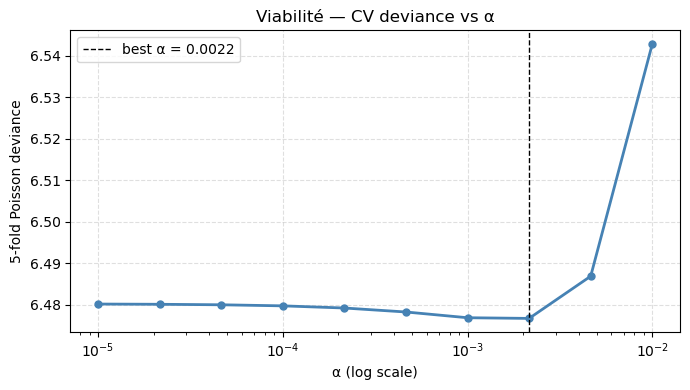

In [6]:
def poisson_deviance(y, mu_hat):
    """
    Mean per-sample Poisson deviance
    """
    log_term = np.where(y > 0, y * np.log(np.maximum(y, 1e-10) / np.maximum(mu_hat, 1e-10)), 0.0)
    return 2 * np.mean(log_term - (y - mu_hat))


def poisson_cv_deviance(X, y, offset, alphas, kf):
    """
    K-fold CV on Poisson deviance for a range of L2 penalties.
    
    Parameters
    ----------
    X      : (M, p) design matrix  — masked to lambda1p > 0
    y      : (M,)   response counts
    offset : (M,)   log-offset
    alphas : array of L2 penalty strengths
    kf     : KFold splitter
    """
    deviances = np.zeros(len(alphas))

    for i, alpha in enumerate(alphas):
        fold_devs = []
        for tr, val in kf.split(X):
            res = sm.GLM(
                endog  = y[tr],
                exog   = X[tr],
                family = sm.families.Poisson(),
                offset = offset[tr],
            ).fit_regularized(alpha=alpha, L1_wt=0.0, maxiter=30)

            mu_val = res.predict(exog=X[val], offset=offset[val])
            fold_devs.append(poisson_deviance(y[val], mu_val))

        deviances[i] = np.mean(fold_devs)
        print(f'  α={alpha:8.4f}  deviance={deviances[i]:.6f}', flush=True)

    return deviances



mask_viab  = np.array(lambda1p > 0)
X_viab_m   = X_bias[mask_viab]
y_viab_m   = np.array(lambda1p, dtype=float)[mask_viab]
off_viab_m = offset_viab[mask_viab]

print(f'CV sur {mask_viab.sum()} séquences informatives')

alphas  = np.logspace(-5, -2, 10)
K_FOLDS = 5
kf      = KFold(n_splits=K_FOLDS, shuffle=True, random_state=0)

cv_deviance_viab = poisson_cv_deviance(X_viab_m, y_viab_m, off_viab_m, alphas, kf)

alpha_best_viab = alphas[np.argmin(cv_deviance_viab)]
print(f'\nBest α viabilité : {alpha_best_viab:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(alphas, cv_deviance_viab, color='steelblue', lw=2, marker='o', ms=5)
ax.axvline(alpha_best_viab, color='k', linestyle='--', lw=1,
           label=f'best α = {alpha_best_viab:.4f}')
ax.set_xlabel('α (log scale)')
ax.set_ylabel(f'{K_FOLDS}-fold Poisson deviance')
ax.set_title('Viabilité — CV deviance vs α')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()


In [7]:
result_viab_reg = sm.GLM(
    endog  = np.array(lambda1p, dtype=float),
    exog   = X_bias,
    family = sm.families.Poisson(),
    offset = offset_viab,
).fit_regularized(alpha=alpha_best_viab, L1_wt=0.0, maxiter=50)

viability_weights_poisson = extract_weights(result_viab_reg, T_viab)
v_hat_poisson = calculate_scores(sequences, viability_weights_poisson)

print(f'Pearson r (scores)  : {pearson(v_gt, v_hat_poisson):.4f}')
print(f'Pearson r (weights) : {pearson(np.array(viability_weights_poisson).flatten(), np.array(viability_weights_GT).flatten()):.4f}')


Pearson r (scores)  : 0.9261
Pearson r (weights) : 0.9172


## 5. Selectivity — Poisson GLM

### Standard approach (noisy offset)

Treat the observed $\lambda_{1,n}'$ as a fixed offset:
$$
n_n^{(2)} \sim \mathrm{Poisson}\!\left(\exp\!\left(\log \lambda_{1,n}' + \frac{\mathbf{x}_n^\top \mathbf{w}^\mathrm{sel}}{T_\mathrm{sel}} + c\right)\right)
$$

**Caveat**: sequences with $\lambda_{1,n}' = 0$ cannot be included (offset = $-\infty$). They must be masked — same as Ridge.  
The errors-in-variables bias is largest for sequences with few viability reads.


CV sur 6464 séquences informatives (sélectivité)
  α=  0.0000  deviance=12.176410
  α=  0.0000  deviance=11.653187
  α=  0.0000  deviance=10.760376
  α=  0.0001  deviance=9.261436
  α=  0.0002  deviance=7.441085
  α=  0.0005  deviance=6.269151
  α=  0.0010  deviance=6.840224
  α=  0.0022  deviance=9.554843
  α=  0.0046  deviance=14.116861
  α=  0.0100  deviance=20.111104

Best α sélectivité : 0.0005


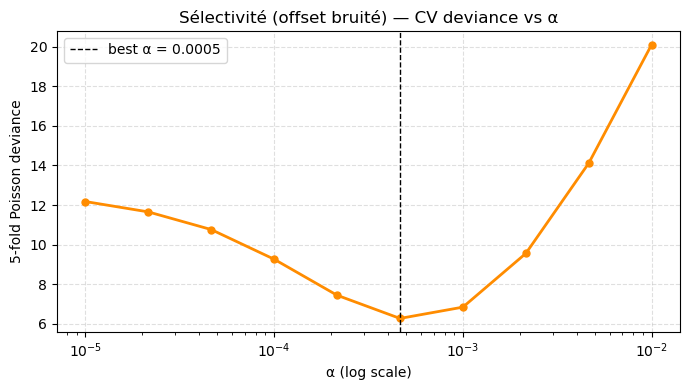

Pearson r (scores)  : 0.9474
Pearson r (weights) : 0.9114


In [8]:
mask_sel   = np.array(lambda1p > 0)
X_sel      = X_bias[mask_sel]
n2_sel     = np.array(n2, dtype=float)[mask_sel]
offset_sel = np.log(np.array(lambda1p, dtype=float)[mask_sel])

print(f'CV sur {mask_sel.sum()} séquences informatives (sélectivité)')

# Cross Validation
cv_deviance_sel = poisson_cv_deviance(X_sel, n2_sel, offset_sel, alphas, kf)
alpha_best_sel  = alphas[np.argmin(cv_deviance_sel)]
print(f'\nBest α sélectivité : {alpha_best_sel:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(alphas, cv_deviance_sel, color='darkorange', lw=2, marker='o', ms=5)
ax.axvline(alpha_best_sel, color='k', linestyle='--', lw=1, label=f'best α = {alpha_best_sel:.4f}')
ax.set_xlabel('α (log scale)')
ax.set_ylabel(f'{K_FOLDS}-fold Poisson deviance')
ax.set_title('Sélectivité (offset bruité) — CV deviance vs α')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

result_sel = sm.GLM(
    endog  = n2_sel,
    exog   = X_sel,
    family = sm.families.Poisson(),
    offset = offset_sel,
).fit_regularized(alpha=alpha_best_sel, L1_wt=0.0, maxiter=50)

selectivity_weights_poisson = extract_weights(result_sel, T_sel)
s_gt          = calculate_scores(sequences, selectivity_weights_GT)
s_hat_noisy   = calculate_scores(sequences, selectivity_weights_poisson)

print(f'Pearson r (scores)  : {pearson(s_gt, s_hat_noisy):.4f}')
print(f'Pearson r (weights) : {pearson(np.array(selectivity_weights_poisson).flatten(), np.array(selectivity_weights_GT).flatten()):.4f}')


## 6. Effect of regularisation strength — why α≈0 wins

The CV in Section 4 uses a coarse grid `logspace(-2, 2)`.
The best deviance may fall at the leftmost point, suggesting the optimum is at **very low α**.

This section sweeps a fine grid over `[1e-8, 1e-1]` and plots:
- Pearson r (scores) vs α — shows the signal captured
- Poisson deviance vs α — the CV criterion

The hypothesis: the Poisson likelihood itself provides implicit regularisation through count
structure. A small α is needed only to resolve the rank-deficiency (7 structural dependencies
of the one-hot encoding); beyond that, more regularisation hurts.


In [9]:
# After some computation, low values for alpha performed the best
alphas_fine = np.logspace(-8, 0, 5)

pearson_viab_vs_alpha = []
pearson_sel_vs_alpha  = []

for alpha in alphas_fine:
    # Viability
    res_v = sm.GLM(
        endog=np.array(lambda1p, dtype=float), exog=X_bias,
        family=sm.families.Poisson(), offset=offset_viab,
    ).fit_regularized(alpha=alpha, L1_wt=0.0, maxiter=50)
    wv = extract_weights(res_v, T_viab)
    vh = calculate_scores(sequences, wv)
    pearson_viab_vs_alpha.append(pearson(v_gt, vh))

    # Selectivity (noisy offset, masked)
    res_s = sm.GLM(
        endog=n2_sel, exog=X_sel,
        family=sm.families.Poisson(), offset=offset_sel,
    ).fit_regularized(alpha=alpha, L1_wt=0.0, maxiter=50)
    ws = extract_weights(res_s, T_sel)
    sh = calculate_scores(sequences, ws)
    pearson_sel_vs_alpha.append(pearson(s_gt, sh))

    print(f'α={alpha:.2e}  r_viab={pearson_viab_vs_alpha[-1]:+.4f}  r_sel={pearson_sel_vs_alpha[-1]:+.4f}',
          flush=True)

pearson_viab_vs_alpha = np.array(pearson_viab_vs_alpha)
pearson_sel_vs_alpha  = np.array(pearson_sel_vs_alpha)


α=1.00e-08  r_viab=+0.9832  r_sel=+0.9017
α=1.00e-06  r_viab=+0.9832  r_sel=+0.9581
α=1.00e-04  r_viab=+0.9783  r_sel=+0.9651
α=1.00e-02  r_viab=+0.8983  r_sel=+0.8601
α=1.00e+00  r_viab=+0.8373  r_sel=+0.5566


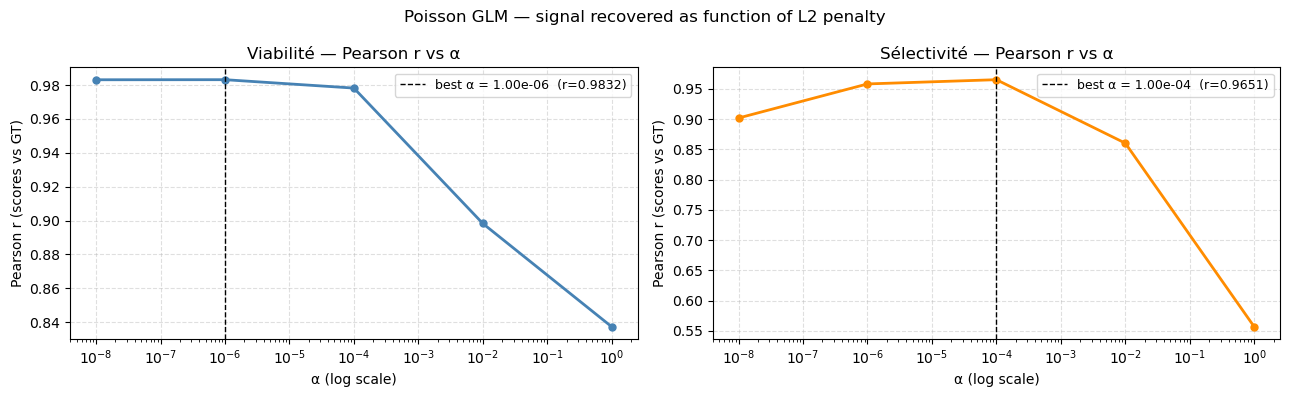

α optimal (Pearson) — viabilité   : 1.00e-06
α optimal (Pearson) — sélectivité : 1.00e-04


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, r_vals, label, color in [
    (axes[0], pearson_viab_vs_alpha, 'Viabilité',   'steelblue'),
    (axes[1], pearson_sel_vs_alpha,  'Sélectivité', 'darkorange'),
]:
    ax.semilogx(alphas_fine, r_vals, color=color, lw=2, marker='o', ms=5)
    best_idx = np.argmax(r_vals)
    ax.axvline(alphas_fine[best_idx], color='k', linestyle='--', lw=1,
               label=f'best α = {alphas_fine[best_idx]:.2e}  (r={r_vals[best_idx]:.4f})')
    ax.set_xlabel('α (log scale)')
    ax.set_ylabel('Pearson r (scores vs GT)')
    ax.set_title(f'{label} — Pearson r vs α')
    ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Poisson GLM — signal recovered as function of L2 penalty', fontsize=12)
plt.tight_layout(); plt.show()

# Best alphas from signal perspective
alpha_opt_viab = alphas_fine[np.argmax(pearson_viab_vs_alpha)]
alpha_opt_sel  = alphas_fine[np.argmax(pearson_sel_vs_alpha)]
print(f'α optimal (Pearson) — viabilité   : {alpha_opt_viab:.2e}')
print(f'α optimal (Pearson) — sélectivité : {alpha_opt_sel:.2e}')


In [11]:
result_viab_opt = sm.GLM(
    endog=np.array(lambda1p, dtype=float), exog=X_bias,
    family=sm.families.Poisson(), offset=offset_viab,
).fit_regularized(alpha=alpha_opt_viab, L1_wt=0.0, maxiter=50)

result_sel_opt = sm.GLM(
    endog=n2_sel, exog=X_sel,
    family=sm.families.Poisson(), offset=offset_sel,
).fit_regularized(alpha=alpha_opt_sel, L1_wt=0.0, maxiter=50)

viability_weights_opt   = extract_weights(result_viab_opt, T_viab)
selectivity_weights_opt = extract_weights(result_sel_opt,  T_sel)

v_hat_opt = calculate_scores(sequences, viability_weights_opt)
s_hat_opt = calculate_scores(sequences, selectivity_weights_opt)

print(f'Pearson r (scores)  viabilité   : {pearson(v_gt, v_hat_opt):.4f}')
print(f'Pearson r (scores)  sélectivité : {pearson(s_gt, s_hat_opt):.4f}')
print(f'Pearson r (weights) viabilité   : {pearson(np.array(viability_weights_opt).flatten(), np.array(viability_weights_GT).flatten()):.4f}')
print(f'Pearson r (weights) sélectivité : {pearson(np.array(selectivity_weights_opt).flatten(), np.array(selectivity_weights_GT).flatten()):.4f}')


Pearson r (scores)  viabilité   : 0.9832
Pearson r (scores)  sélectivité : 0.9651
Pearson r (weights) viabilité   : 0.9738
Pearson r (weights) sélectivité : 0.9285


## 7. Precision@k

In [12]:
s_gt = calculate_scores(sequences, selectivity_weights_GT)

combined_gt  = np.array(v_gt)     / T_viab + np.array(s_gt)     / T_sel
combined_opt = np.array(v_hat_opt) / T_viab + np.array(s_hat_opt) / T_sel

fracs = [0.01, 0.05, 0.10, 0.20]
print('  Top-%    Precision@k   (random baseline = top-%)')
print('  ──────────────────────────────────────────────────')
for frac in fracs:
    p = precision_at_k(combined_gt, combined_opt, k_frac=frac)
    print(f'  Top {int(frac*100):3d}%      {p:.3f}          (baseline: {frac:.3f})')


  Top-%    Precision@k   (random baseline = top-%)
  ──────────────────────────────────────────────────
  Top   1%      0.839          (baseline: 0.010)
  Top   5%      0.864          (baseline: 0.050)
  Top  10%      0.879          (baseline: 0.100)
  Top  20%      0.895          (baseline: 0.200)


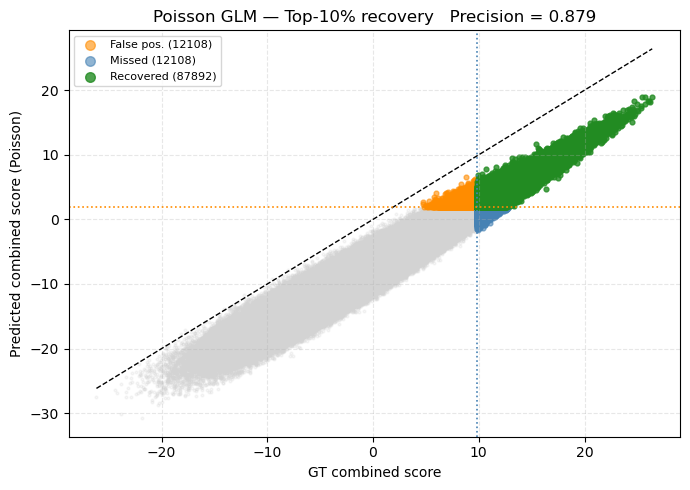

In [13]:
k10      = int(num_sequences * 0.10)
top_gt   = set(np.argsort(-combined_gt)[:k10])
top_hat  = set(np.argsort(-combined_opt)[:k10])
both     = np.array(sorted(top_gt & top_hat))
only_gt  = np.array(sorted(top_gt  - top_hat))
only_hat = np.array(sorted(top_hat - top_gt))
rest     = np.array(sorted(set(range(num_sequences)) - top_gt - top_hat))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(combined_gt[rest],     combined_opt[rest],     s=4,  alpha=0.2, color='lightgray')
ax.scatter(combined_gt[only_hat], combined_opt[only_hat], s=12, alpha=0.6, color='darkorange',
           label=f'False pos. ({len(only_hat)})')
ax.scatter(combined_gt[only_gt],  combined_opt[only_gt],  s=12, alpha=0.6, color='steelblue',
           label=f'Missed ({len(only_gt)})')
ax.scatter(combined_gt[both],     combined_opt[both],     s=12, alpha=0.8, color='forestgreen',
           label=f'Recovered ({len(both)})')
lo, hi = combined_gt.min(), combined_gt.max()
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
ax.axvline(np.sort(combined_gt)[-k10],  color='steelblue',  linestyle=':', lw=1.2)
ax.axhline(np.sort(combined_opt)[-k10], color='darkorange', linestyle=':', lw=1.2)
ax.set_xlabel('GT combined score')
ax.set_ylabel('Predicted combined score (Poisson)')
p10 = precision_at_k(combined_gt, combined_opt, k_frac=0.10)
ax.set_title(f'Poisson GLM — Top-10% recovery   Precision = {p10:.3f}')
ax.legend(fontsize=8, markerscale=2); ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Ridge vs Poisson — comparaison finale

In [14]:
def fit_ridge_local(X, y, T, alpha):
    n_params = X.shape[1] - 1
    P = np.zeros((X.shape[1], X.shape[1]))
    P[:n_params, :n_params] = alpha * np.eye(n_params)
    coef = np.linalg.solve(X.T @ X + P, X.T @ np.array(y))
    w = coef[:-1].reshape(num_positions, num_amino_acids).T
    return jnp.array(w * T)

def ridge_cv_mse_local(X, y, alphas, kf):
    mse = np.zeros(len(alphas))
    n_params = X.shape[1] - 1
    for i, a in enumerate(alphas):
        P = np.zeros((X.shape[1], X.shape[1]))
        P[:n_params, :n_params] = a * np.eye(n_params)
        fold_mse = []
        for tr, val in kf.split(X):
            coef = np.linalg.solve(X[tr].T @ X[tr] + P, X[tr].T @ y[tr])
            fold_mse.append(np.mean((X[val] @ coef - y[val]) ** 2))
        mse[i] = np.mean(fold_mse)
    return mse

eps       = 0.5
n0_norm   = n0       / jnp.sum(n0)       * jnp.sum(lambda1p)
l1p_norm  = lambda1p / jnp.sum(lambda1p) * jnp.sum(n2)
y_viab_r  = np.array(jnp.log((lambda1p + eps) / (n0_norm  + eps)))
y_sel_r   = np.array(jnp.log((n2       + eps) / (l1p_norm + eps)))

mask_v  = np.array(lambda1p > 0)
mask_s  = np.array(n2 > 0)
_kf     = KFold(n_splits=5, shuffle=True, random_state=0)
_alphas = np.logspace(-2, 2, 20)

cv_v = ridge_cv_mse_local(X_bias[mask_v], y_viab_r[mask_v], _alphas, _kf)
cv_s = ridge_cv_mse_local(X_bias[mask_s], y_sel_r[mask_s],  _alphas, _kf)

wv_ridge = fit_ridge_local(X_bias[mask_v], y_viab_r[mask_v], T_viab, _alphas[np.argmin(cv_v)])
ws_ridge = fit_ridge_local(X_bias[mask_s], y_sel_r[mask_s],  T_sel,  _alphas[np.argmin(cv_s)])
vh_ridge = calculate_scores(sequences, wv_ridge)
sh_ridge = calculate_scores(sequences, ws_ridge)

cgt = np.array(v_gt) / T_viab + np.array(s_gt) / T_sel

methods = {
    'Ridge (CV)':         (vh_ridge,   sh_ridge),
    'Poisson (α_CV)':     (v_hat_poisson, s_hat_noisy),
    'Poisson (α_opt)':    (v_hat_opt,  s_hat_opt),
}

print(f'  {"Méthode":<22}  r_viab   r_sel    Prec@1%  Prec@10%')
print(f'  {"─"*58}')
for name, (vh, sh) in methods.items():
    comb = np.array(vh) / T_viab + np.array(sh) / T_sel
    print(f'  {name:<22}  {pearson(v_gt,vh):+.4f}  {pearson(s_gt,sh):+.4f}  '
          f' {precision_at_k(cgt, comb, 0.01):.3f}    {precision_at_k(cgt, comb, 0.10):.3f}')


  Méthode                 r_viab   r_sel    Prec@1%  Prec@10%
  ──────────────────────────────────────────────────────────
  Ridge (CV)              +0.9900  +0.9135   0.660    0.758
  Poisson (α_CV)          +0.9261  +0.9474   0.653    0.753
  Poisson (α_opt)         +0.9832  +0.9651   0.839    0.879


## 9. Impact of noise on results.

In the method protocol, two paramaters impact on noise, the epsilon for variability and selectivity, previously, they were set to 0.5 arbitrary, we want to know if a very noisy model will affect the results significantly and especially which model between Poisson and Ridge regression is the most robust.

### Which phase is more affected by noise?

In [15]:
# 3 epsilon values for viability noise (selectivity noise fixed at default)
epsilons_viab = [0.1, 0.3, 0.8]
eps_sel_fixed = 0.3  # keep selectivity noise at default

v_gt = calculate_scores(sequences, viability_weights_GT)
s_gt = calculate_scores(sequences, selectivity_weights_GT)

prec10_viab = []
pearson_viab_eps = []

for eps in epsilons_viab:
    _, _caps, lambda1p_eps, _n2 = protocol(
        n0, sequences,
        viability_weights_GT, selectivity_weights_GT,
        epsilon_viability=eps,
        epsilon_selectivity=eps_sel_fixed,
        use_full_ngs=False,
    )
    _offset = np.log(np.array(n0, dtype=float) + 0.5)
    _res = sm.GLM(
        endog=np.array(lambda1p_eps, dtype=float), exog=X_bias,
        family=sm.families.Poisson(), offset=_offset,
    ).fit_regularized(alpha=alpha_opt_viab, L1_wt=0.0, maxiter=50)
    _w  = extract_weights(_res, T_viab)
    _vh = np.array(calculate_scores(sequences, _w))
    _r  = pearson(v_gt, _vh)
    _p  = precision_at_k(v_gt, _vh, k_frac=0.10)
    prec10_viab.append(_p)
    pearson_viab_eps.append(_r)
    print(f'ε_viab={eps:.1f}  Pearson r={_r:.4f}  Precision@10%={_p:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, ylabel, title in [
    (axes[0], pearson_viab_eps, 'Pearson r',       'Pearson r (scores vs GT)'),
    (axes[1], prec10_viab,      'Precision@10%',   'Top-10% recovery'),
]:
    bars = ax.bar([str(e) for e in epsilons_viab], vals, color='steelblue', alpha=0.8, width=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_xlabel('ε viability (noise level)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Viabilité — {title} vs ε')
    ax.set_ylim(0, max(vals) * 1.2 + 0.05)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.suptitle('Impact of viability noise — Poisson GLM (α_opt)', fontsize=12)
plt.tight_layout(); plt.show()


The maximum score value for viability is = 4.687632083892822
Pearson r (scores) for epsilon = 0.30000001192092896 : 0.9261
Pearson r (weights) for epsilon = 0.30000001192092896 : 0.9172 

Pearson r (scores) for epsilon = 1.0312719345092773 : 0.9087
Pearson r (weights) for epsilon = 1.0312719345092773 : 0.8999 

Pearson r (scores) for epsilon = 1.7625439167022705 : 0.8361
Pearson r (weights) for epsilon = 1.7625439167022705 : 0.8277 

Pearson r (scores) for epsilon = 2.4938158988952637 : 0.6038
Pearson r (weights) for epsilon = 2.4938158988952637 : 0.5971 

Pearson r (scores) for epsilon = 3.225087881088257 : 0.4065
Pearson r (weights) for epsilon = 3.225087881088257 : 0.4017 

Pearson r (scores) for epsilon = 3.95635986328125 : 0.2816
Pearson r (weights) for epsilon = 3.95635986328125 : 0.2782 

Pearson r (scores) for epsilon = 4.687632083892822 : 0.2919
Pearson r (weights) for epsilon = 4.687632083892822 : 0.2891 



In [ ]:
# 3 epsilon values for selectivity noise (viability noise fixed at default)
epsilons_sel = [0.1, 0.3, 0.8]
eps_viab_fixed = 0.3  # keep viability noise at default

prec10_sel = []
pearson_sel_eps = []

for eps in epsilons_sel:
    _, _caps, lambda1p_eps2, n2_eps2 = protocol(
        n0, sequences,
        viability_weights_GT, selectivity_weights_GT,
        epsilon_viability=eps_viab_fixed,
        epsilon_selectivity=eps,
        use_full_ngs=False,
    )
    _mask       = np.array(lambda1p_eps2 > 0)
    _X_sel      = X_bias[_mask]
    _n2_sel     = np.array(n2_eps2[_mask], dtype=float)
    _lam1p_m    = np.array(lambda1p_eps2[_mask], dtype=float)
    _off_sel    = np.log(_lam1p_m + 0.5)
    _res_s = sm.GLM(
        endog=_n2_sel, exog=_X_sel,
        family=sm.families.Poisson(), offset=_off_sel,
    ).fit_regularized(alpha=alpha_opt_sel, L1_wt=0.0, maxiter=50)
    _ws  = extract_weights(_res_s, T_sel)
    _sh  = np.array(calculate_scores(sequences, _ws))
    _r   = pearson(s_gt, _sh)
    _p   = precision_at_k(s_gt, _sh, k_frac=0.10)
    prec10_sel.append(_p)
    pearson_sel_eps.append(_r)
    print(f'ε_sel={eps:.1f}  Pearson r={_r:.4f}  Precision@10%={_p:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, ylabel, title in [
    (axes[0], pearson_sel_eps, 'Pearson r',     'Pearson r (scores vs GT)'),
    (axes[1], prec10_sel,      'Precision@10%', 'Top-10% recovery'),
]:
    bars = ax.bar([str(e) for e in epsilons_sel], vals, color='darkorange', alpha=0.8, width=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_xlabel('ε selectivity (noise level)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Sélectivité — {title} vs ε')
    ax.set_ylim(0, max(vals) * 1.2 + 0.05)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.suptitle('Impact of selectivity noise — Poisson GLM (α_opt)', fontsize=12)
plt.tight_layout(); plt.show()
